# 04 — Siamese CNN per FCGR di eccDNA

## Obiettivo

Questo notebook implementa il primo modello Siamese della pipeline.

Ogni ramo della rete riceve una FCGR normalizzata e utilizza lo stesso
CNN encoder per trasformarla in un embedding.

La pipeline è:

DNA / eccDNA
→ FCGR
→ CNN encoder condiviso
→ embedding
→ distanza euclidea
→ Contrastive Loss

Le coppie positive appartengono alla stessa classe patologica, mentre le
coppie negative appartengono a classi differenti.

In questa prima baseline vengono utilizzati:

- FCGR con `k = 6` (`64 × 64`);
- embedding dimension = `128`;
- distanza euclidea;
- Contrastive Loss;
- target `1` per coppie positive;
- target `0` per coppie negative.

La classificazione multiclass tramite prototipi degli embedding verrà
affrontata successivamente.

In [1]:
from pathlib import Path

import json
import random
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)


print(
    "PyTorch:",
    torch.__version__
)

print(
    "CUDA disponibile:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

PyTorch: 2.12.0+cu126
CUDA disponibile: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
CURRENT_DIR = (
    Path.cwd()
    .resolve()
)


if CURRENT_DIR.name == "notebooks":

    PROJECT_ROOT = (
        CURRENT_DIR.parent
    )

else:

    PROJECT_ROOT = (
        CURRENT_DIR
    )


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "siamese_baseline_C"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PAIR_CONFIG_PATH = (
    PROCESSED_DIR
    / "siamese_pair_config.json"
)


MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_primary_manifest.tsv"
)


VAL_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_val_pair_pool.tsv"
)


TEST_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_test_pair_pool.tsv"
)


with open(
    PAIR_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    PAIR_CONFIG = json.load(f)


DEFAULT_K = int(
    PAIR_CONFIG["k"]
)


# ============================================================
# BASELINE B
# ============================================================

ORIGINAL_BATCH_SIZE = int(
    PAIR_CONFIG["batch_size"]
)

BATCH_SIZE = 128


TRAIN_PAIRS_PER_EPOCH = int(
    PAIR_CONFIG[
        "train_pairs_per_epoch"
    ]
)


VAL_PAIRS = int(
    PAIR_CONFIG["val_pairs"]
)


TEST_PAIRS = int(
    PAIR_CONFIG["test_pairs"]
)


POSITIVE_PAIR_PROBABILITY = float(
    PAIR_CONFIG[
        "positive_probability"
    ]
)


RANDOM_STATE = int(
    PAIR_CONFIG["random_state"]
)


FCGR_MEMMAP_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / f"fcgr_k{DEFAULT_K}.npy"
)


FCGR_INDEX_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / f"fcgr_k{DEFAULT_K}_index.tsv"
)


print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "k:",
    DEFAULT_K
)

print(
    "Batch Baseline A:",
    ORIGINAL_BATCH_SIZE
)

print(
    "Batch Baseline B:",
    BATCH_SIZE
)

print(
    "Train pairs / epoch:",
    TRAIN_PAIRS_PER_EPOCH
)

Project root: D:\Daria\Desktop\eccdna_fcgr_siamese
k: 7
Batch Baseline A: 64
Batch Baseline B: 128
Train pairs / epoch: 50000


In [3]:
def set_seed(
    seed
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


set_seed(
    RANDOM_STATE
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    DEVICE
)

if DEVICE.type == "cuda":

    torch.backends.cudnn.benchmark = True

    torch.set_float32_matmul_precision(
        "high"
    )


print(
    "cuDNN benchmark:",
    torch.backends.cudnn.benchmark
)

Device: cuda
cuDNN benchmark: True


In [4]:
metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


val_pair_pool = pd.read_csv(
    VAL_POOL_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


test_pair_pool = pd.read_csv(
    TEST_POOL_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


train_metadata = (
    metadata[
        metadata[
            "split_cluster"
        ] == "train"
    ]
    .copy()
)


for dataframe in [
    train_metadata,
    val_pair_pool,
    test_pair_pool
]:

    dataframe[
        "class_id"
    ] = (
        dataframe[
            "class_id"
        ]
        .astype(int)
    )


print(
    "Train samples:",
    f"{len(train_metadata):,}"
)

print(
    "Validation pool:",
    f"{len(val_pair_pool):,}"
)

print(
    "Test pool:",
    f"{len(test_pair_pool):,}"
)

print(
    "Classi:",
    train_metadata[
        "class_id"
    ].nunique()
)

Train samples: 126,265
Validation pool: 12,937
Test pool: 11,070
Classi: 18


In [5]:
fcgr_memmap = np.load(
    FCGR_MEMMAP_PATH,
    mmap_mode="r"
)


fcgr_index = pd.read_csv(
    FCGR_INDEX_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


id_to_fcgr_row = dict(
    zip(
        fcgr_index[
            "id"
        ],

        fcgr_index[
            "fcgr_row"
        ]
    )
)


print(
    "FCGR shape:",
    fcgr_memmap.shape
)

print(
    "FCGR dtype:",
    fcgr_memmap.dtype
)

print(
    "Indice:",
    len(
        id_to_fcgr_row
    )
)


assert (
    fcgr_memmap.dtype
    == np.float32
)


assert (
    len(
        id_to_fcgr_row
    )
    ==
    fcgr_memmap.shape[0]
)

FCGR shape: (150272, 128, 128)
FCGR dtype: float32
Indice: 150272


In [6]:
class SiamesePairDataset(
    Dataset
):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row,
        pairs_per_epoch,
        positive_probability=0.5,
        seed=42,
        deterministic=False
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )


        self.fcgr_memmap = (
            fcgr_memmap
        )


        self.id_to_row = (
            id_to_row
        )


        self.pairs_per_epoch = int(
            pairs_per_epoch
        )


        self.positive_probability = float(
            positive_probability
        )


        self.seed = int(
            seed
        )


        self.deterministic = (
            deterministic
        )


        self.rng = (
            np.random.default_rng(
                self.seed
            )
        )


        self.class_to_ids = {

            int(class_id):
            group["id"]
            .astype(str)
            .tolist()

            for class_id, group
            in self.metadata.groupby(
                "class_id"
            )
        }


        self.classes = np.array(
            sorted(
                self.class_to_ids.keys()
            ),
            dtype=np.int64
        )


        for class_id in self.classes:

            if (
                len(
                    self.class_to_ids[
                        int(class_id)
                    ]
                )
                < 2
            ):

                raise ValueError(
                    f"Classe {class_id} "
                    "con meno di 2 sample."
                )


    def __len__(
        self
    ):

        return (
            self.pairs_per_epoch
        )


    def _get_rng(
        self,
        index
    ):

        if self.deterministic:

            return (
                np.random.default_rng(
                    self.seed
                    + int(index)
                )
            )

        return (
            self.rng
        )


    def _sample_pair(
        self,
        rng
    ):

        # ----------------------------------
        # Classe anchor
        # ----------------------------------

        class1 = int(
            rng.choice(
                self.classes
            )
        )


        ids_class1 = (
            self.class_to_ids[
                class1
            ]
        )


        id1 = str(
            rng.choice(
                ids_class1
            )
        )


        # ----------------------------------
        # Positive pair
        # ----------------------------------

        if (
            rng.random()
            <
            self.positive_probability
        ):

            class2 = (
                class1
            )


            id2 = (
                id1
            )


            while (
                id2
                ==
                id1
            ):

                id2 = str(
                    rng.choice(
                        ids_class1
                    )
                )


            target = (
                1.0
            )


        # ----------------------------------
        # Negative pair
        # ----------------------------------

        else:

            possible_classes = (
                self.classes[
                    self.classes
                    != class1
                ]
            )


            class2 = int(
                rng.choice(
                    possible_classes
                )
            )


            id2 = str(
                rng.choice(
                    self.class_to_ids[
                        class2
                    ]
                )
            )


            target = (
                0.0
            )


        return (
            id1,
            id2,
            class1,
            class2,
            target
        )


    def _load_fcgr(
        self,
        sample_id
    ):

        row = (
            self.id_to_row[
                str(sample_id)
            ]
        )


        fcgr = np.array(
            self.fcgr_memmap[
                row
            ],
            dtype=np.float32,
            copy=True
        )


        tensor = (
            torch.from_numpy(
                fcgr
            )
            .unsqueeze(0)
        )


        return tensor


    def __getitem__(
        self,
        index
    ):

        rng = (
            self._get_rng(
                index
            )
        )


        (
            id1,
            id2,
            class1,
            class2,
            target
        ) = (
            self._sample_pair(
                rng
            )
        )


        x1 = (
            self._load_fcgr(
                id1
            )
        )


        x2 = (
            self._load_fcgr(
                id2
            )
        )


        return {

            "x1":
                x1,

            "x2":
                x2,

            "target":
                torch.tensor(
                    target,
                    dtype=torch.float32
                ),

            "id1":
                id1,

            "id2":
                id2,

            "class1":
                class1,

            "class2":
                class2
        }

In [9]:
train_dataset = SiamesePairDataset(

    metadata=
        train_metadata,

    fcgr_memmap=
        fcgr_memmap,

    id_to_row=
        id_to_fcgr_row,

    pairs_per_epoch=
        TRAIN_PAIRS_PER_EPOCH,

    positive_probability=
        POSITIVE_PAIR_PROBABILITY,

    seed=
        RANDOM_STATE,

    deterministic=False
)


val_dataset = SiamesePairDataset(

    metadata=
        val_pair_pool,

    fcgr_memmap=
        fcgr_memmap,

    id_to_row=
        id_to_fcgr_row,

    pairs_per_epoch=
        VAL_PAIRS,

    positive_probability=
        POSITIVE_PAIR_PROBABILITY,

    seed=
        RANDOM_STATE + 10_000,

    deterministic=True
)


test_dataset = SiamesePairDataset(

    metadata=
        test_pair_pool,

    fcgr_memmap=
        fcgr_memmap,

    id_to_row=
        id_to_fcgr_row,

    pairs_per_epoch=
        TEST_PAIRS,

    positive_probability=
        POSITIVE_PAIR_PROBABILITY,

    seed=
        RANDOM_STATE + 20_000,

    deterministic=True
)


NUM_WORKERS = 0


train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 391
Validation batches: 79
Test batches: 79


In [10]:
batch = next(
    iter(
        train_loader
    )
)


print(
    "x1:",
    batch["x1"].shape,
    batch["x1"].dtype
)

print(
    "x2:",
    batch["x2"].shape,
    batch["x2"].dtype
)

print(
    "target:",
    batch["target"].shape,
    batch["target"].dtype
)


print()

print(
    "Positive:",
    (
        batch[
            "target"
        ] == 1
    ).sum().item()
)

print(
    "Negative:",
    (
        batch[
            "target"
        ] == 0
    ).sum().item()
)


assert (
    batch["x1"].shape[1:]
    ==
    (
        1,
        64,
        64
    )
)


assert (
    batch["x1"].dtype
    ==
    torch.float32
)

x1: torch.Size([128, 1, 128, 128]) torch.float32
x2: torch.Size([128, 1, 128, 128]) torch.float32
target: torch.Size([128]) torch.float32

Positive: 68
Negative: 60


AssertionError: 

# CNN Encoder

La rete Siamese utilizza un unico CNN encoder condiviso tra i due rami.

Questo significa che entrambe le FCGR vengono processate dagli stessi
parametri θ:

`z1 = Encoder(x1)`

`z2 = Encoder(x2)`

L'encoder produce un embedding di 128 dimensioni.

Gli embedding vengono normalizzati tramite norma L2. In questo modo
la loro scala rimane controllata e la distanza euclidea dipende
principalmente dalla posizione relativa dei sample nello spazio degli
embedding.

In [11]:
class FCGRCNNEncoder(
    nn.Module
):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.features = nn.Sequential(

            # ==============================
            # 64 x 64
            # ==============================

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=32
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=2
            ),


            # ==============================
            # 32 x 32
            # ==============================

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=64
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=2
            ),


            # ==============================
            # 16 x 16
            # ==============================

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=2
            ),


            # ==============================
            # 8 x 8
            # ==============================

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(
                (
                    4,
                    4
                )
            )
        )


        self.projection = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                256,
                embedding_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(
            x
        )


        z = self.projection(
            x
        )


        z = F.normalize(
            z,
            p=2,
            dim=1
        )


        return z

In [12]:
class SiameseNetwork(
    nn.Module
):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.encoder = FCGRCNNEncoder(
            embedding_dim=
                embedding_dim
        )


    def forward(
        self,
        x1,
        x2
    ):

        # Un'unica chiamata all'encoder
        # invece di due chiamate separate.

        x = torch.cat(
            [
                x1,
                x2
            ],
            dim=0
        )


        z = self.encoder(
            x
        )


        z1, z2 = torch.chunk(
            z,
            chunks=2,
            dim=0
        )


        return (
            z1,
            z2
        )

In [13]:
class ContrastiveLoss(
    nn.Module
):

    def __init__(
        self,
        margin=1.0
    ):

        super().__init__()

        self.margin = float(
            margin
        )


    def forward(
        self,
        z1,
        z2,
        target
    ):

        distance = (
            F.pairwise_distance(
                z1,
                z2,
                p=2
            )
        )


        positive_loss = (
            target
            *
            distance.pow(2)
        )


        negative_loss = (

            (1.0 - target)

            *

            F.relu(
                self.margin
                -
                distance
            ).pow(2)
        )


        loss = (
            positive_loss
            +
            negative_loss
        )


        return (
            loss.mean(),
            distance
        )

In [14]:
EMBEDDING_DIM = 128

MARGIN = 1.0


model = SiameseNetwork(
    embedding_dim=
        EMBEDDING_DIM
)


model = model.to(
    DEVICE
)


criterion = ContrastiveLoss(
    margin=
        MARGIN
)


n_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)


n_trainable_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


print(
    model
)


print()

print(
    "Parametri totali:",
    f"{n_parameters:,}"
)

print(
    "Parametri trainabili:",
    f"{n_trainable_parameters:,}"
)

SiameseNetwork(
  (encoder): FCGRCNNEncoder(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): GroupNorm(8, 128, eps=1e-05, affine=True, bias=True)
      (12): ReLU(inplace=True)
      (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (14): Conv2d(128, 128, kernel_size=(3, 3)

In [15]:
model.eval()


x1 = (
    batch["x1"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


x2 = (
    batch["x2"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


targets = (
    batch["target"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    z1, z2 = model(
        x1,
        x2
    )


    loss, distances = criterion(
        z1,
        z2,
        targets
    )


print(
    "x1:",
    x1.shape
)

print(
    "z1:",
    z1.shape
)

print(
    "z2:",
    z2.shape
)

print(
    "Loss:",
    loss.item()
)

print(
    "Distance min:",
    distances.min().item()
)

print(
    "Distance max:",
    distances.max().item()
)

print(
    "Distance mean:",
    distances.mean().item()
)

x1: torch.Size([128, 1, 128, 128])
z1: torch.Size([128, 128])
z2: torch.Size([128, 128])
Loss: 0.46455544233322144
Distance min: 0.0004509333230089396
Distance max: 0.02896766923367977
Distance mean: 0.004184644669294357


In [16]:
embedding_norms = torch.linalg.vector_norm(
    z1,
    dim=1
)


print(
    "Norma minima:",
    embedding_norms.min().item()
)

print(
    "Norma massima:",
    embedding_norms.max().item()
)

print(
    "Norma media:",
    embedding_norms.mean().item()
)

Norma minima: 0.9999999403953552
Norma massima: 1.0
Norma media: 1.0


In [17]:
# ============================================================
# TRAIN / EVAL CONSISTENCY CHECK
# ============================================================

diagnostic_batch = next(
    iter(
        val_loader
    )
)


diag_x1 = (
    diagnostic_batch["x1"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


diag_x2 = (
    diagnostic_batch["x2"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


diag_targets = (
    diagnostic_batch["target"]
    .cpu()
    .numpy()
)


# ------------------------------------------------------------
# TRAIN MODE
# ------------------------------------------------------------

model.train()


with torch.no_grad():

    train_z1, train_z2 = model(
        diag_x1,
        diag_x2
    )


    train_distances = (
        F.pairwise_distance(
            train_z1,
            train_z2
        )
        .cpu()
        .numpy()
    )


# ------------------------------------------------------------
# EVAL MODE
# ------------------------------------------------------------

model.eval()


with torch.no_grad():

    eval_z1, eval_z2 = model(
        diag_x1,
        diag_x2
    )


    eval_distances = (
        F.pairwise_distance(
            eval_z1,
            eval_z2
        )
        .cpu()
        .numpy()
    )


print(
    "TRAIN mode mean distance:",
    train_distances.mean()
)

print(
    "EVAL mode mean distance:",
    eval_distances.mean()
)


print(
    "Differenza media:",
    np.abs(
        train_distances
        -
        eval_distances
    ).mean()
)


print()

print(
    "TRAIN d+:",
    train_distances[
        diag_targets == 1
    ].mean()
)

print(
    "TRAIN d-:",
    train_distances[
        diag_targets == 0
    ].mean()
)


print(
    "EVAL d+:",
    eval_distances[
        diag_targets == 1
    ].mean()
)

print(
    "EVAL d-:",
    eval_distances[
        diag_targets == 0
    ].mean()
)

TRAIN mode mean distance: 0.004116795
EVAL mode mean distance: 0.004116795
Differenza media: 0.0

TRAIN d+: 0.0047296807
TRAIN d-: 0.003522767
EVAL d+: 0.0047296807
EVAL d-: 0.003522767


# Training

Il modello viene ottimizzato mediante AdamW.

Il training utilizza coppie generate dinamicamente ad ogni epoca,
mentre validation e test utilizzano coppie deterministiche.

Il checkpoint viene selezionato sulla `validation contrastive loss`.

Il test set non viene utilizzato durante il training né per la scelta
dell'epoca migliore.

In [23]:
EPOCHS = 45

LEARNING_RATE = 5e-4

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 7

MIN_AUC_DELTA = 1e-4


CHECKPOINT_PATH = (
    ARTIFACTS_DIR
    / "best_siamese_baseline_C.pt"
)


HISTORY_PATH = (
    ARTIFACTS_DIR
    / "training_history_C_semplice.csv"
)


print(
    "Epoch:",
    EPOCHS
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Patience:",
    EARLY_STOPPING_PATIENCE
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

Epoch: 45
Learning rate: 0.0005
Batch size: 128
Patience: 7
Checkpoint: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_baseline_C\best_siamese_baseline_C.pt


In [19]:
def run_epoch(
    model,
    loader,
    criterion,
    device,
    optimizer=None,
    scaler=None
):

    training = (
        optimizer
        is not None
    )


    if training:

        model.train()

    else:

        model.eval()


    total_loss = 0.0

    total_samples = 0


    all_distances = []

    all_targets = []


    for batch in loader:

        x1 = (
            batch["x1"]
            .to(
                device,
                non_blocking=True
            )
        )


        x2 = (
            batch["x2"]
            .to(
                device,
                non_blocking=True
            )
        )


        targets = (
            batch["target"]
            .to(
                device,
                non_blocking=True
            )
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):

            with torch.autocast(

                device_type=
                    device.type,

                dtype=
                    torch.float16,

                enabled=
                    (
                        device.type
                        ==
                        "cuda"
                    )
            ):

                z1, z2 = model(
                    x1,
                    x2
                )


                loss, distances = (
                    criterion(
                        z1,
                        z2,
                        targets
                    )
                )


        if training:

            scaler.scale(
                loss
            ).backward()


            scaler.step(
                optimizer
            )


            scaler.update()


        batch_size = (
            targets.shape[0]
        )


        total_loss += (
            loss.item()
            *
            batch_size
        )


        total_samples += (
            batch_size
        )


        all_distances.append(

            distances
            .detach()
            .cpu()
            .numpy()
        )


        all_targets.append(

            targets
            .detach()
            .cpu()
            .numpy()
        )


    all_distances = (
        np.concatenate(
            all_distances
        )
    )


    all_targets = (
        np.concatenate(
            all_targets
        )
        .astype(int)
    )


    average_loss = (
        total_loss
        /
        total_samples
    )


    positive_distances = (
        all_distances[
            all_targets == 1
        ]
    )


    negative_distances = (
        all_distances[
            all_targets == 0
        ]
    )


    return {

        "loss":
            average_loss,

        "mean_positive_distance":
            positive_distances.mean(),

        "mean_negative_distance":
            negative_distances.mean(),

        "distances":
            all_distances,

        "targets":
            all_targets
    }

In [20]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,

    fused=
        (
            DEVICE.type
            ==
            "cuda"
        )
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=0.5,

        patience=3
    )
)


USE_AMP = (
    DEVICE.type
    ==
    "cuda"
)


scaler = torch.amp.GradScaler(

    "cuda",

    enabled=
        USE_AMP
)


print(
    "Mixed precision:",
    USE_AMP
)

print(
    "Fused AdamW:",
    DEVICE.type == "cuda"
)

Mixed precision: True
Fused AdamW: True


In [24]:
# ============================================================
# RESUME BASELINE C DAL BEST CHECKPOINT
# ============================================================

print(
    "Caricamento best checkpoint:",
    CHECKPOINT_PATH
)


checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)


# ------------------------------------------------------------
# Ripristino pesi del modello
# ------------------------------------------------------------

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


# ------------------------------------------------------------
# Ripristino optimizer
# ------------------------------------------------------------

optimizer.load_state_dict(
    checkpoint[
        "optimizer_state_dict"
    ]
)


# ------------------------------------------------------------
# Best epoch precedente
# ------------------------------------------------------------

BEST_PREVIOUS_EPOCH = int(
    checkpoint[
        "epoch"
    ]
)


best_val_auc = float(
    checkpoint[
        "val_roc_auc"
    ]
)


START_EPOCH = (
    BEST_PREVIOUS_EPOCH
    + 1
)


# ------------------------------------------------------------
# Recupero history precedente
# ------------------------------------------------------------

history_df_previous = pd.read_csv(
    HISTORY_PATH
)


# Poiché ripartiamo dal BEST checkpoint,
# eliminiamo dall'history eventuali epoche
# successive al best epoch.
#
# Nel nostro caso il best era epoch 19,
# quindi la vecchia epoch 20 viene scartata
# e verrà ricalcolata.

history_df_previous = (
    history_df_previous[
        history_df_previous[
            "epoch"
        ]
        <=
        BEST_PREVIOUS_EPOCH
    ]
    .copy()
)


history = (
    history_df_previous
    .to_dict(
        orient="records"
    )
)


epochs_without_improvement = 0


print()
print(
    "Best epoch precedente:",
    BEST_PREVIOUS_EPOCH
)

print(
    "Best validation ROC-AUC:",
    best_val_auc
)

print(
    "Ripresa da epoch:",
    START_EPOCH
)

print(
    "Epoch finale massima:",
    EPOCHS
)

print(
    "Learning rate ripristinato:",
    optimizer.param_groups[0]["lr"]
)

print(
    "Righe history recuperate:",
    len(history)
)

Caricamento best checkpoint: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_baseline_C\best_siamese_baseline_C.pt

Best epoch precedente: 44
Best validation ROC-AUC: 0.6847674170412886
Ripresa da epoch: 45
Epoch finale massima: 45
Learning rate ripristinato: 3.125e-05
Righe history recuperate: 44


In [22]:
training_start = (
    time.perf_counter()
)


for epoch in range(
    START_EPOCH,
    EPOCHS + 1
):

    epoch_start = (
        time.perf_counter()
    )


    # ========================================================
    # TRAIN
    # ========================================================

    train_results = run_epoch(

        model=
            model,

        loader=
            train_loader,

        criterion=
            criterion,

        device=
            DEVICE,

        optimizer=
            optimizer,

        scaler=
            scaler
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    val_results = run_epoch(

        model=
            model,

        loader=
            val_loader,

        criterion=
            criterion,

        device=
            DEVICE
    )


    val_loss = (
        val_results[
            "loss"
        ]
    )


    val_positive_distance = float(
        val_results[
            "mean_positive_distance"
        ]
    )


    val_negative_distance = float(
        val_results[
            "mean_negative_distance"
        ]
    )


    val_distance_gap = (
        val_negative_distance
        -
        val_positive_distance
    )


    # La coppia positiva deve avere
    # distanza più piccola.
    # Quindi usiamo -distance come
    # similarity score.

    val_roc_auc = roc_auc_score(

        val_results[
            "targets"
        ],

        -val_results[
            "distances"
        ]
    )


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step(
        val_roc_auc
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    epoch_time = (
        time.perf_counter()
        -
        epoch_start
    )


    # ========================================================
    # HISTORY
    # ========================================================

    history.append({

        "epoch":
            epoch,

        "train_loss":
            train_results[
                "loss"
            ],

        "val_loss":
            val_loss,

        "train_positive_distance":
            train_results[
                "mean_positive_distance"
            ],

        "train_negative_distance":
            train_results[
                "mean_negative_distance"
            ],

        "val_positive_distance":
            val_positive_distance,

        "val_negative_distance":
            val_negative_distance,

        "val_distance_gap":
            val_distance_gap,

        "val_roc_auc":
            val_roc_auc,

        "learning_rate":
            current_lr,

        "epoch_seconds":
            epoch_time
    })


    print(

        f"Epoch {epoch:02d}/{EPOCHS}"

        f" | train_loss="
        f"{train_results['loss']:.5f}"

        f" | val_loss="
        f"{val_loss:.5f}"

        f" | d+="
        f"{val_positive_distance:.4f}"

        f" | d-="
        f"{val_negative_distance:.4f}"

        f" | gap="
        f"{val_distance_gap:.4f}"

        f" | AUC="
        f"{val_roc_auc:.4f}"

        f" | lr="
        f"{current_lr:.2e}"

        f" | {epoch_time:.1f}s"
    )


    # ========================================================
    # CHECKPOINT SU VALIDATION ROC-AUC
    # ========================================================

    if (
        val_roc_auc
        >
        best_val_auc
        +
        MIN_AUC_DELTA
    ):

        best_val_auc = (
            val_roc_auc
        )


        epochs_without_improvement = (
            0
        )


        torch.save(

            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                scheduler.state_dict(),

                "val_loss":
                    val_loss,

                "val_roc_auc":
                    val_roc_auc,

                "val_distance_gap":
                    val_distance_gap,

                "embedding_dim":
                    EMBEDDING_DIM,

                "margin":
                    MARGIN,

                "learning_rate":
                    LEARNING_RATE,

                "batch_size":
                    BATCH_SIZE,

                "normalization":
                    "GroupNorm",

                "k":
                    DEFAULT_K
            },

            CHECKPOINT_PATH
        )


        print(
            "  → nuovo best checkpoint AUC"
        )


    else:

        epochs_without_improvement += 1


        print(

            "  → no AUC improvement:",

            epochs_without_improvement,

            "/",

            EARLY_STOPPING_PATIENCE
        )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()
        print(
            "Early stopping."
        )

        break


training_seconds = (
    time.perf_counter()
    -
    training_start
)


print()
print(
    "Training terminato."
)

print(
    "Tempo totale:",
    f"{training_seconds / 60:.2f} min"
)

print(
    "Best validation ROC-AUC:",
    best_val_auc
)

KeyboardInterrupt: 

In [25]:
history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


display(
    history_df
)

,epoch,train_loss,val_loss,train_positive_distance,train_negative_distance,val_positive_distance,val_negative_distance,val_distance_gap,val_roc_auc,learning_rate,epoch_seconds
0,1,0.275724,0.246729,0.396616,0.450213,0.449830,0.502362,0.052532,0.598116,0.000500,135.376293
1,2,0.244798,0.244249,0.453171,0.511753,0.433381,0.495122,0.061741,0.614594,0.000500,116.582419
2,3,0.241217,0.237460,0.453069,0.515964,0.467380,0.539822,0.072442,0.633345,0.000500,114.015992
3,4,0.238012,0.236440,0.453051,0.525123,0.457679,0.535199,0.077519,0.638560,0.000500,115.677554
4,5,0.236599,0.236031,0.452279,0.526984,0.465689,0.535241,0.069552,0.637634,0.000500,115.240432
5,6,0.235741,0.233153,0.457461,0.534160,0.468013,0.549917,0.081903,0.649657,0.000500,115.884125
6,7,0.235098,0.230344,0.452488,0.529332,0.445548,0.530129,0.084582,0.661958,0.000500,115.534885
7,8,0.234738,0.231228,0.454006,0.531939,0.459892,0.539970,0.080078,0.656857,0.000500,115.577649
8,9,0.235251,0.230901,0.452242,0.528531,0.444746,0.530413,0.085667,0.659457,0.000500,114.984122
9,10,0.234098,0.229107,0.451272,0.530908,0.456493,0.544189,0.087696,0.665381,0.000500,114.332581


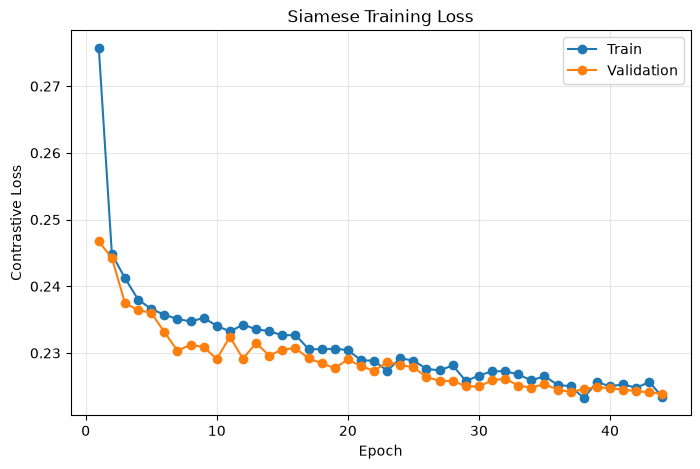

In [26]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train"
)


plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Contrastive Loss"
)

plt.title(
    "Siamese Training Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

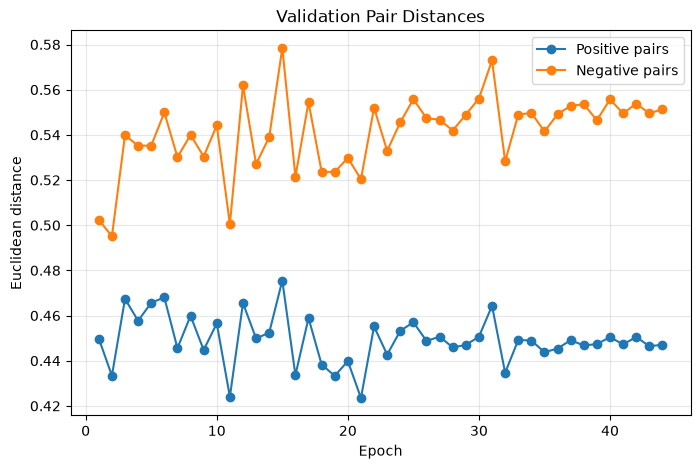

In [27]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(

    history_df["epoch"],

    history_df[
        "val_positive_distance"
    ],

    marker="o",

    label=
        "Positive pairs"
)


plt.plot(

    history_df["epoch"],

    history_df[
        "val_negative_distance"
    ],

    marker="o",

    label=
        "Negative pairs"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Euclidean distance"
)

plt.title(
    "Validation Pair Distances"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [28]:
checkpoint = torch.load(

    CHECKPOINT_PATH,

    map_location=
        DEVICE,

    weights_only=False
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)

print(
    "Best validation ROC-AUC:",
    checkpoint["val_roc_auc"]
)

print(
    "Best distance gap:",
    checkpoint["val_distance_gap"]
)

Best epoch: 44
Best validation loss: 0.22386611742973328
Best validation ROC-AUC: 0.6847674170412886
Best distance gap: 0.10432222485542297


In [29]:
val_results = run_epoch(

    model=
        model,

    loader=
        val_loader,

    criterion=
        criterion,

    device=
        DEVICE
)


val_distances = (
    val_results[
        "distances"
    ]
)


val_targets = (
    val_results[
        "targets"
    ]
)


print(
    "Validation loss:",
    val_results["loss"]
)

print(
    "Mean positive distance:",
    val_results[
        "mean_positive_distance"
    ]
)

print(
    "Mean negative distance:",
    val_results[
        "mean_negative_distance"
    ]
)

Validation loss: 0.25593060722351074
Mean positive distance: 0.34260872
Mean negative distance: 0.4013841


In [30]:
def find_best_threshold(
    targets,
    distances,
    n_thresholds=500
):

    thresholds = np.linspace(

        distances.min(),

        distances.max(),

        n_thresholds
    )


    best_threshold = None

    best_f1 = -1


    for threshold in thresholds:

        predictions = (
            distances
            <=
            threshold
        ).astype(int)


        score = f1_score(

            targets,

            predictions,

            average="macro"
        )


        if score > best_f1:

            best_f1 = (
                score
            )

            best_threshold = (
                threshold
            )


    return (
        best_threshold,
        best_f1
    )


best_threshold, val_macro_f1 = (
    find_best_threshold(

        val_targets,

        val_distances
    )
)


print(
    "Best threshold:",
    best_threshold
)

print(
    "Validation Macro F1:",
    val_macro_f1
)

Best threshold: 0.37081566
Validation Macro F1: 0.587061146583282


In [31]:
def compute_pair_metrics(
    targets,
    distances,
    threshold
):

    predictions = (
        distances
        <=
        threshold
    ).astype(int)


    similarity_scores = (
        -distances
    )


    return {

        "accuracy":
            accuracy_score(
                targets,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                targets,
                predictions
            ),

        "macro_f1":
            f1_score(
                targets,
                predictions,
                average="macro"
            ),

        "precision":
            precision_score(
                targets,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                targets,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                targets,
                similarity_scores
            )
    }


val_metrics = (
    compute_pair_metrics(

        val_targets,

        val_distances,

        best_threshold
    )
)


pd.DataFrame(
    [val_metrics]
)

,accuracy,balanced_accuracy,macro_f1,precision,recall,roc_auc
0,0.5871,0.58716,0.587061,0.582699,0.599678,0.620876


In [32]:
test_results = run_epoch(

    model=
        model,

    loader=
        test_loader,

    criterion=
        criterion,

    device=
        DEVICE
)


test_distances = (
    test_results[
        "distances"
    ]
)


test_targets = (
    test_results[
        "targets"
    ]
)


test_metrics = (
    compute_pair_metrics(

        test_targets,

        test_distances,

        best_threshold
    )
)


print(
    "Test loss:",
    test_results["loss"]
)

print(
    "Positive distance:",
    test_results[
        "mean_positive_distance"
    ]
)

print(
    "Negative distance:",
    test_results[
        "mean_negative_distance"
    ]
)


display(
    pd.DataFrame(
        [test_metrics]
    )
)

Test loss: 0.25692108409404757
Positive distance: 0.34319276
Negative distance: 0.40038338


,accuracy,balanced_accuracy,macro_f1,precision,recall,roc_auc
0,0.5834,0.583442,0.583336,0.579685,0.597593,0.6165


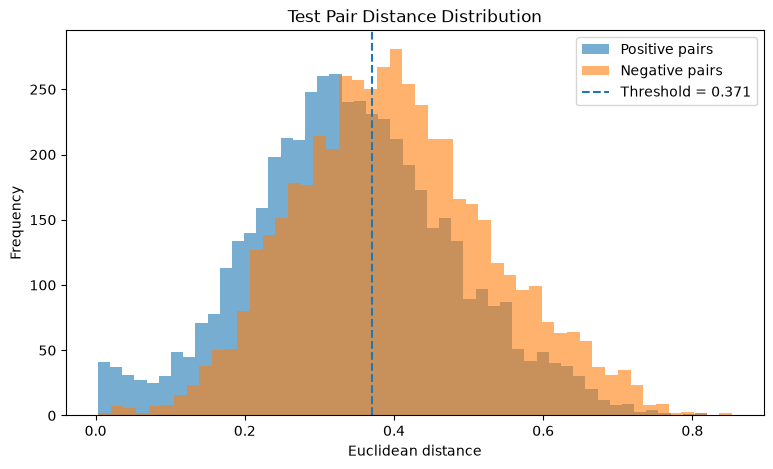

In [33]:
positive_test_distances = (
    test_distances[
        test_targets == 1
    ]
)


negative_test_distances = (
    test_distances[
        test_targets == 0
    ]
)


plt.figure(
    figsize=(9, 5)
)


plt.hist(

    positive_test_distances,

    bins=50,

    alpha=0.6,

    label=
        "Positive pairs"
)


plt.hist(

    negative_test_distances,

    bins=50,

    alpha=0.6,

    label=
        "Negative pairs"
)


plt.axvline(

    best_threshold,

    linestyle="--",

    label=
        f"Threshold = "
        f"{best_threshold:.3f}"
)


plt.xlabel(
    "Euclidean distance"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Test Pair Distance Distribution"
)

plt.legend()

plt.show()

[[2855 2160]
 [2006 2979]]


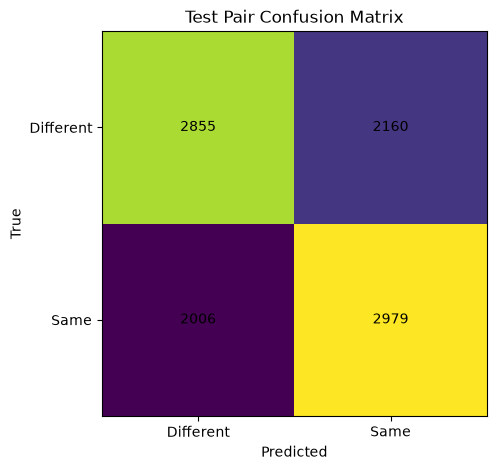

In [34]:
test_predictions = (

    test_distances
    <=
    best_threshold

).astype(int)


cm = confusion_matrix(

    test_targets,

    test_predictions,

    labels=[
        0,
        1
    ]
)


print(
    cm
)


fig, ax = plt.subplots(
    figsize=(5, 5)
)


image = ax.imshow(
    cm
)


ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)


ax.set_xticklabels(
    [
        "Different",
        "Same"
    ]
)


ax.set_yticklabels(
    [
        "Different",
        "Same"
    ]
)


ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "True"
)


ax.set_title(
    "Test Pair Confusion Matrix"
)


for i in range(2):

    for j in range(2):

        ax.text(

            j,
            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center"
        )


plt.show()

In [31]:
RESULTS_PATH = (
    ARTIFACTS_DIR
    / "pair_metrics_C.json"
)


results = {

    "best_epoch":
        int(
            checkpoint["epoch"]
        ),

    "best_val_loss":
        float(
            checkpoint["val_loss"]
        ),

    "threshold":
        float(
            best_threshold
        ),

    "embedding_dim":
        EMBEDDING_DIM,

    "margin":
        MARGIN,

    "k":
        DEFAULT_K,

    "validation":
        {
            key:
                float(value)

            for key, value
            in val_metrics.items()
        },

    "test":
        {
            key:
                float(value)

            for key, value
            in test_metrics.items()
        },

    "best_val_roc_auc":
    float(
        checkpoint[
            "val_roc_auc"
        ]
    ),

    "normalization":
        "GroupNorm",

    "learning_rate":
        LEARNING_RATE,

    "batch_size":
        BATCH_SIZE,

    "forward_strategy":
        "concatenated",
}


with open(
    RESULTS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )


print(
    "Risultati salvati:",
    RESULTS_PATH
)

Risultati salvati: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_baseline_C\pair_metrics_C.json


In [35]:
# ============================================================
# 18-CLASS RANKING — SINGLE SAMPLE DATASET
# ============================================================

class SingleFCGRDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )

        self.fcgr_memmap = fcgr_memmap

        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )

        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )


    def __len__(self):

        return len(self.metadata)


    def __getitem__(
        self,
        index
    ):

        x = np.array(
            self.fcgr_memmap[
                int(self.rows[index])
            ],
            dtype=np.float32,
            copy=True
        )

        return {
            "x":
                torch.from_numpy(x)
                .unsqueeze(0),

            "label":
                torch.tensor(
                    self.labels[index],
                    dtype=torch.long
                )
        }

In [36]:
# ============================================================
# 18-CLASS REFERENCE + TEST
# ============================================================

reference_metadata = (
    train_metadata
    .copy()
    .reset_index(drop=True)
)


test_metadata_18 = (
    test_pair_pool
    .drop_duplicates(
        subset="id"
    )
    .copy()
    .reset_index(drop=True)
)


N_CLASSES_18 = (
    reference_metadata[
        "class_id"
    ]
    .nunique()
)


class_table_18 = (
    reference_metadata[
        [
            "class_id",
            "disease_clean"
        ]
    ]
    .drop_duplicates()
    .sort_values("class_id")
)


class_names_18 = (
    class_table_18[
        "disease_clean"
    ]
    .tolist()
)


print("=" * 72)
print("18-CLASS RANKING SETUP")
print("=" * 72)

print(
    "Reference samples:",
    len(reference_metadata)
)

print(
    "Test samples:",
    len(test_metadata_18)
)

print(
    "Classes:",
    N_CLASSES_18
)


display(
    class_table_18
)

18-CLASS RANKING SETUP
Reference samples: 126265
Test samples: 11070
Classes: 18


,class_id,disease_clean
0,0,gastric cancer
10000,1,healthy
20000,2,ovarian cancer
30000,3,prostate cancer
40000,4,colorectal cancer
50000,5,lymphoma
60000,6,hiv infectious disease
70000,7,cervical adenocarcinoma
80000,8,leukemia
90000,9,primary pulmonary hypertension


In [37]:
reference_dataset_18 = SingleFCGRDataset(
    reference_metadata,
    fcgr_memmap,
    id_to_fcgr_row
)


test_dataset_18 = SingleFCGRDataset(
    test_metadata_18,
    fcgr_memmap,
    id_to_fcgr_row
)


reference_loader_18 = DataLoader(
    reference_dataset_18,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=(
        DEVICE.type == "cuda"
    )
)


test_loader_18 = DataLoader(
    test_dataset_18,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=(
        DEVICE.type == "cuda"
    )
)

In [38]:
# ============================================================
# EXTRACT 128D EMBEDDINGS
# ============================================================

@torch.no_grad()
def extract_embeddings(
    encoder,
    loader
):

    encoder.eval()

    embeddings = []
    labels = []


    for batch in loader:

        x = batch["x"].to(
            DEVICE,
            non_blocking=True
        )

        z = encoder(x)

        embeddings.append(
            z.float()
            .cpu()
            .numpy()
        )

        labels.append(
            batch["label"]
            .numpy()
        )


    return (
        np.concatenate(
            embeddings,
            axis=0
        ),
        np.concatenate(
            labels,
            axis=0
        )
    )


reference_embeddings_18, reference_labels_18 = (
    extract_embeddings(
        model.encoder,
        reference_loader_18
    )
)


test_embeddings_18, test_labels_18 = (
    extract_embeddings(
        model.encoder,
        test_loader_18
    )
)


print(
    "Reference embeddings:",
    reference_embeddings_18.shape
)

print(
    "Test embeddings:",
    test_embeddings_18.shape
)

print(
    "Mean norm:",
    np.linalg.norm(
        test_embeddings_18,
        axis=1
    ).mean()
)

Reference embeddings: (126265, 128)
Test embeddings: (11070, 128)
Mean norm: 1.0


In [39]:
# ============================================================
# 18-CLASS REFERENCE BANK
# ============================================================

reference_bank_18 = {}


for class_id in range(
    N_CLASSES_18
):

    reference_bank_18[
        class_id
    ] = (
        reference_embeddings_18[
            reference_labels_18
            ==
            class_id
        ]
    )


for class_id in range(
    N_CLASSES_18
):

    print(
        f"{class_id:2d} | "
        f"{class_names_18[class_id]:40s} | "
        f"{reference_bank_18[class_id].shape[0]}"
    )

 0 | gastric cancer                           | 10000
 1 | healthy                                  | 10000
 2 | ovarian cancer                           | 10000
 3 | prostate cancer                          | 10000
 4 | colorectal cancer                        | 10000
 5 | lymphoma                                 | 10000
 6 | hiv infectious disease                   | 10000
 7 | cervical adenocarcinoma                  | 10000
 8 | leukemia                                 | 10000
 9 | primary pulmonary hypertension           | 6987
10 | cataract                                 | 6896
11 | hypopharyngeal squamous cell carcinoma   | 5052
12 | glioblastoma cancer                      | 4880
13 | melanoma                                 | 4124
14 | dilated cardiomyopathy                   | 2601
15 | hypopharynx cancer                       | 2111
16 | chronic kidney disease                   | 1859
17 | branchio-oculo-facial syndrome (bofs)    | 1755


In [40]:
# ============================================================
# TOP-20 COSINE SIMILARITY — 18 CLASSES
# ============================================================

@torch.no_grad()
def compute_class_similarity_matrix(
    query_embeddings,
    reference_bank,
    n_classes,
    top_k=20,
    batch_size=256
):

    class_refs = {}


    for class_id in range(
        n_classes
    ):

        class_refs[class_id] = (
            torch.from_numpy(
                reference_bank[
                    class_id
                ]
            )
            .float()
            .to(DEVICE)
        )


    all_scores = []


    for start in range(
        0,
        len(query_embeddings),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(query_embeddings)
        )


        queries = (
            torch.from_numpy(
                query_embeddings[
                    start:end
                ]
            )
            .float()
            .to(DEVICE)
        )


        batch_scores = []


        for class_id in range(
            n_classes
        ):

            refs = class_refs[
                class_id
            ]


            similarities = (
                queries
                @
                refs.T
            )


            k = min(
                top_k,
                refs.shape[0]
            )


            top_values = torch.topk(
                similarities,
                k=k,
                dim=1,
                largest=True
            ).values


            class_score = (
                top_values.mean(
                    dim=1
                )
            )


            batch_scores.append(
                class_score
            )


        batch_scores = torch.stack(
            batch_scores,
            dim=1
        )


        all_scores.append(
            batch_scores
            .cpu()
            .numpy()
        )


    return np.concatenate(
        all_scores,
        axis=0
    )


test_similarity_18 = (
    compute_class_similarity_matrix(
        query_embeddings=
            test_embeddings_18,

        reference_bank=
            reference_bank_18,

        n_classes=
            N_CLASSES_18,

        top_k=20
    )
)


test_ranking_18 = np.argsort(
    -test_similarity_18,
    axis=1
)


print(
    "Similarity matrix:",
    test_similarity_18.shape
)

Similarity matrix: (11070, 18)


In [41]:
# ============================================================
# TOP-K ACCURACY — 18 CLASS BASELINE
# ============================================================

def topk_accuracy(
    ranking,
    labels,
    k
):

    return np.mean(
        np.any(
            ranking[:, :k]
            ==
            labels[:, None],
            axis=1
        )
    )


top1_18 = topk_accuracy(
    test_ranking_18,
    test_labels_18,
    1
)


top2_18 = topk_accuracy(
    test_ranking_18,
    test_labels_18,
    2
)


top3_18 = topk_accuracy(
    test_ranking_18,
    test_labels_18,
    3
)


print("=" * 72)
print("18-CLASS BASELINE — TEST RANKING")
print("=" * 72)

print(
    "Top-1:",
    f"{top1_18:.4f}",
    f"({100*top1_18:.2f}%)"
)

print(
    "Top-2:",
    f"{top2_18:.4f}",
    f"({100*top2_18:.2f}%)"
)

print(
    "Top-3:",
    f"{top3_18:.4f}",
    f"({100*top3_18:.2f}%)"
)

18-CLASS BASELINE — TEST RANKING
Top-1: 0.3019 (30.19%)
Top-2: 0.4871 (48.71%)
Top-3: 0.6192 (61.92%)


In [42]:
# ============================================================
# BALANCED TOP-K — 18 CLASSES
# ============================================================

def balanced_topk_accuracy(
    ranking,
    labels,
    n_classes,
    k
):

    recalls = []


    for class_id in range(
        n_classes
    ):

        mask = (
            labels
            ==
            class_id
        )


        class_topk = (
            ranking[
                mask,
                :k
            ]
        )


        class_labels = (
            labels[
                mask
            ]
        )


        hit = np.any(
            class_topk
            ==
            class_labels[:, None],
            axis=1
        )


        recalls.append(
            hit.mean()
        )


    return float(
        np.mean(
            recalls
        )
    )


bal_top1_18 = (
    balanced_topk_accuracy(
        test_ranking_18,
        test_labels_18,
        N_CLASSES_18,
        1
    )
)


bal_top2_18 = (
    balanced_topk_accuracy(
        test_ranking_18,
        test_labels_18,
        N_CLASSES_18,
        2
    )
)


bal_top3_18 = (
    balanced_topk_accuracy(
        test_ranking_18,
        test_labels_18,
        N_CLASSES_18,
        3
    )
)


print("=" * 72)
print("18-CLASS BASELINE — BALANCED RANKING")
print("=" * 72)

print(
    "Balanced Top-1:",
    f"{bal_top1_18:.4f}",
    f"({100*bal_top1_18:.2f}%)"
)

print(
    "Balanced Top-2:",
    f"{bal_top2_18:.4f}",
    f"({100*bal_top2_18:.2f}%)"
)

print(
    "Balanced Top-3:",
    f"{bal_top3_18:.4f}",
    f"({100*bal_top3_18:.2f}%)"
)

18-CLASS BASELINE — BALANCED RANKING
Balanced Top-1: 0.2354 (23.54%)
Balanced Top-2: 0.3766 (37.66%)
Balanced Top-3: 0.4862 (48.62%)


# Conclusioni

È stata implementata una prima CNN Siamese per l'analisi delle FCGR
derivate dalle sequenze eccDNA.

I due input vengono elaborati dallo stesso CNN encoder, che genera
embedding normalizzati di 128 dimensioni.

Il modello viene addestrato mediante Contrastive Loss e distanza euclidea:

- le coppie positive vengono spinte verso distanze ridotte;
- le coppie negative vengono spinte oltre un margine prefissato.

La soglia utilizzata per distinguere pair positivi e negativi viene
determinata esclusivamente sul validation set.

Il test set viene utilizzato solamente dopo la selezione del modello e
della soglia.

Questa configurazione rappresenta la baseline di metric learning del
progetto.

I passi successivi comprenderanno:

- analisi degli embedding;
- classificazione multiclass mediante prototipi di classe;
- confronto con cosine similarity;
- confronto con altre loss metric-learning;
- ablation study sulla dimensione dell'embedding e sul valore di k.